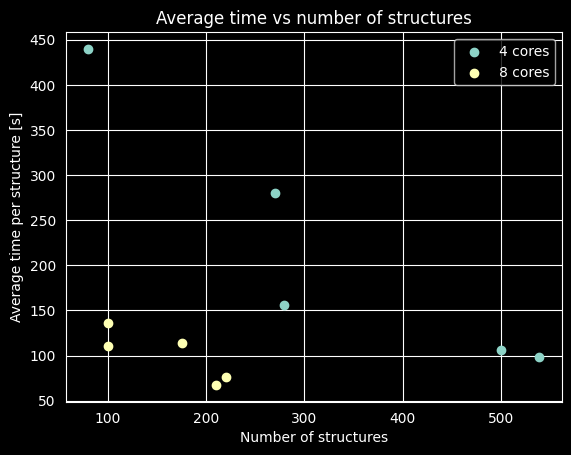

In [1]:
import re
import matplotlib.pyplot as plt


def plot_time_vs_structures(filename):
    data = []

    with open(filename, "r") as f:
        content = f.read()

    blocks = re.split(r'\n\s*\n', content)

    for block in blocks:
        n_struct = re.search(r'Number of structures:\s+(\d+)', block)
        time = re.search(r'Average time per structure \[s\]:\s+([0-9.]+)', block)
        cores = re.search(r'Number of cores:\s+(\d+)', block)

        if n_struct and time and cores:
            data.append({
                "structures": int(n_struct.group(1)),
                "time": float(time.group(1)),
                "cores": int(cores.group(1))
            })

    x_4, y_4 = [], []
    x_8, y_8 = [], []

    for d in data:
        if d["cores"] == 4:
            x_4.append(d["structures"])
            y_4.append(d["time"])
        elif d["cores"] == 8:
            x_8.append(d["structures"])
            y_8.append(d["time"])

    # Plot
    fig, ax = plt.subplots()
    # fig.patch.set_facecolor("white")   # whole figure background
    # ax.set_facecolor("white")          # axes background

    ax.scatter(x_4, y_4, label="4 cores")
    ax.scatter(x_8, y_8, label="8 cores")

    ax.set_xlabel("Number of structures")
    ax.set_ylabel("Average time per structure [s]")
    ax.set_title("Average time vs number of structures")
    ax.legend()

    # No grid (just don't call ax.grid())

    plt.show()

plot_time_vs_structures("num_cores.txt")